# Catchments Demo

Demonstrates the `catchments` function, which generates gully and ridge rasters
from a Digital Elevation Model (DEM) using pysheds.

## Setup

In [1]:
from shelterbelts.indices.catchments import catchments
from shelterbelts.utils.filepaths import get_filename
from shelterbelts.utils.visualisation import plot_catchments, plot_catchments_sidebyside

# Example data
dem_file = get_filename('g2_26729_DEM-H.tif')

## Default Parameters

In [2]:
ds = catchments(dem_file)
ds

Saved: ./TEST_gullies.tif
Saved: ./TEST_ridges.tif
Saved: ./TEST_gullies_and_ridges.png


<xarray.Dataset> Size: 407kB
Dimensions:      (x: 201, y: 201)
Coordinates:
  * x            (x) float64 2kB 6.3e+05 6.3e+05 6.3e+05 ... 6.32e+05 6.32e+05
  * y            (y) float64 2kB 6.196e+06 6.196e+06 ... 6.194e+06 6.194e+06
    spatial_ref  int64 8B 0
Data variables:
    terrain      (y, x) float64 323kB 575.0 575.0 576.1 ... 520.7 520.4 520.4
    gullies      (y, x) bool 40kB False False False False ... False False False
    ridges       (y, x) bool 40kB False False False False ... False False False

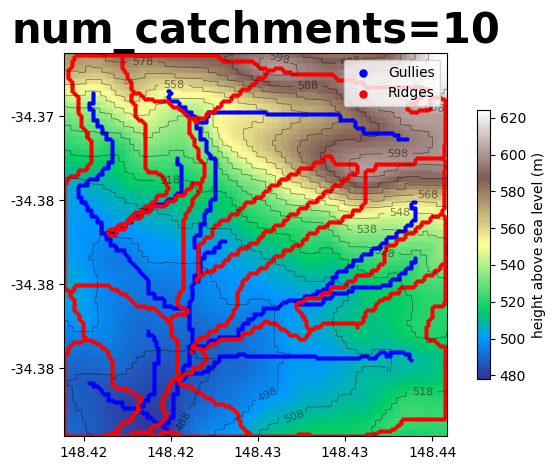

In [3]:
plot_catchments(ds, title="num_catchments=10")

## Changing num_catchments

The `num_catchments` parameter controls how many catchments are identified.

In [4]:
ds5 = catchments(dem_file, stub='num_catchments5', num_catchments=5)
ds20 = catchments(dem_file, stub='num_catchments20', num_catchments=20)

Saved: ./num_catchments5_gullies.tif
Saved: ./num_catchments5_ridges.tif
Saved: ./num_catchments5_gullies_and_ridges.png
Saved: ./num_catchments20_gullies.tif
Saved: ./num_catchments20_ridges.tif
Saved: ./num_catchments20_gullies_and_ridges.png


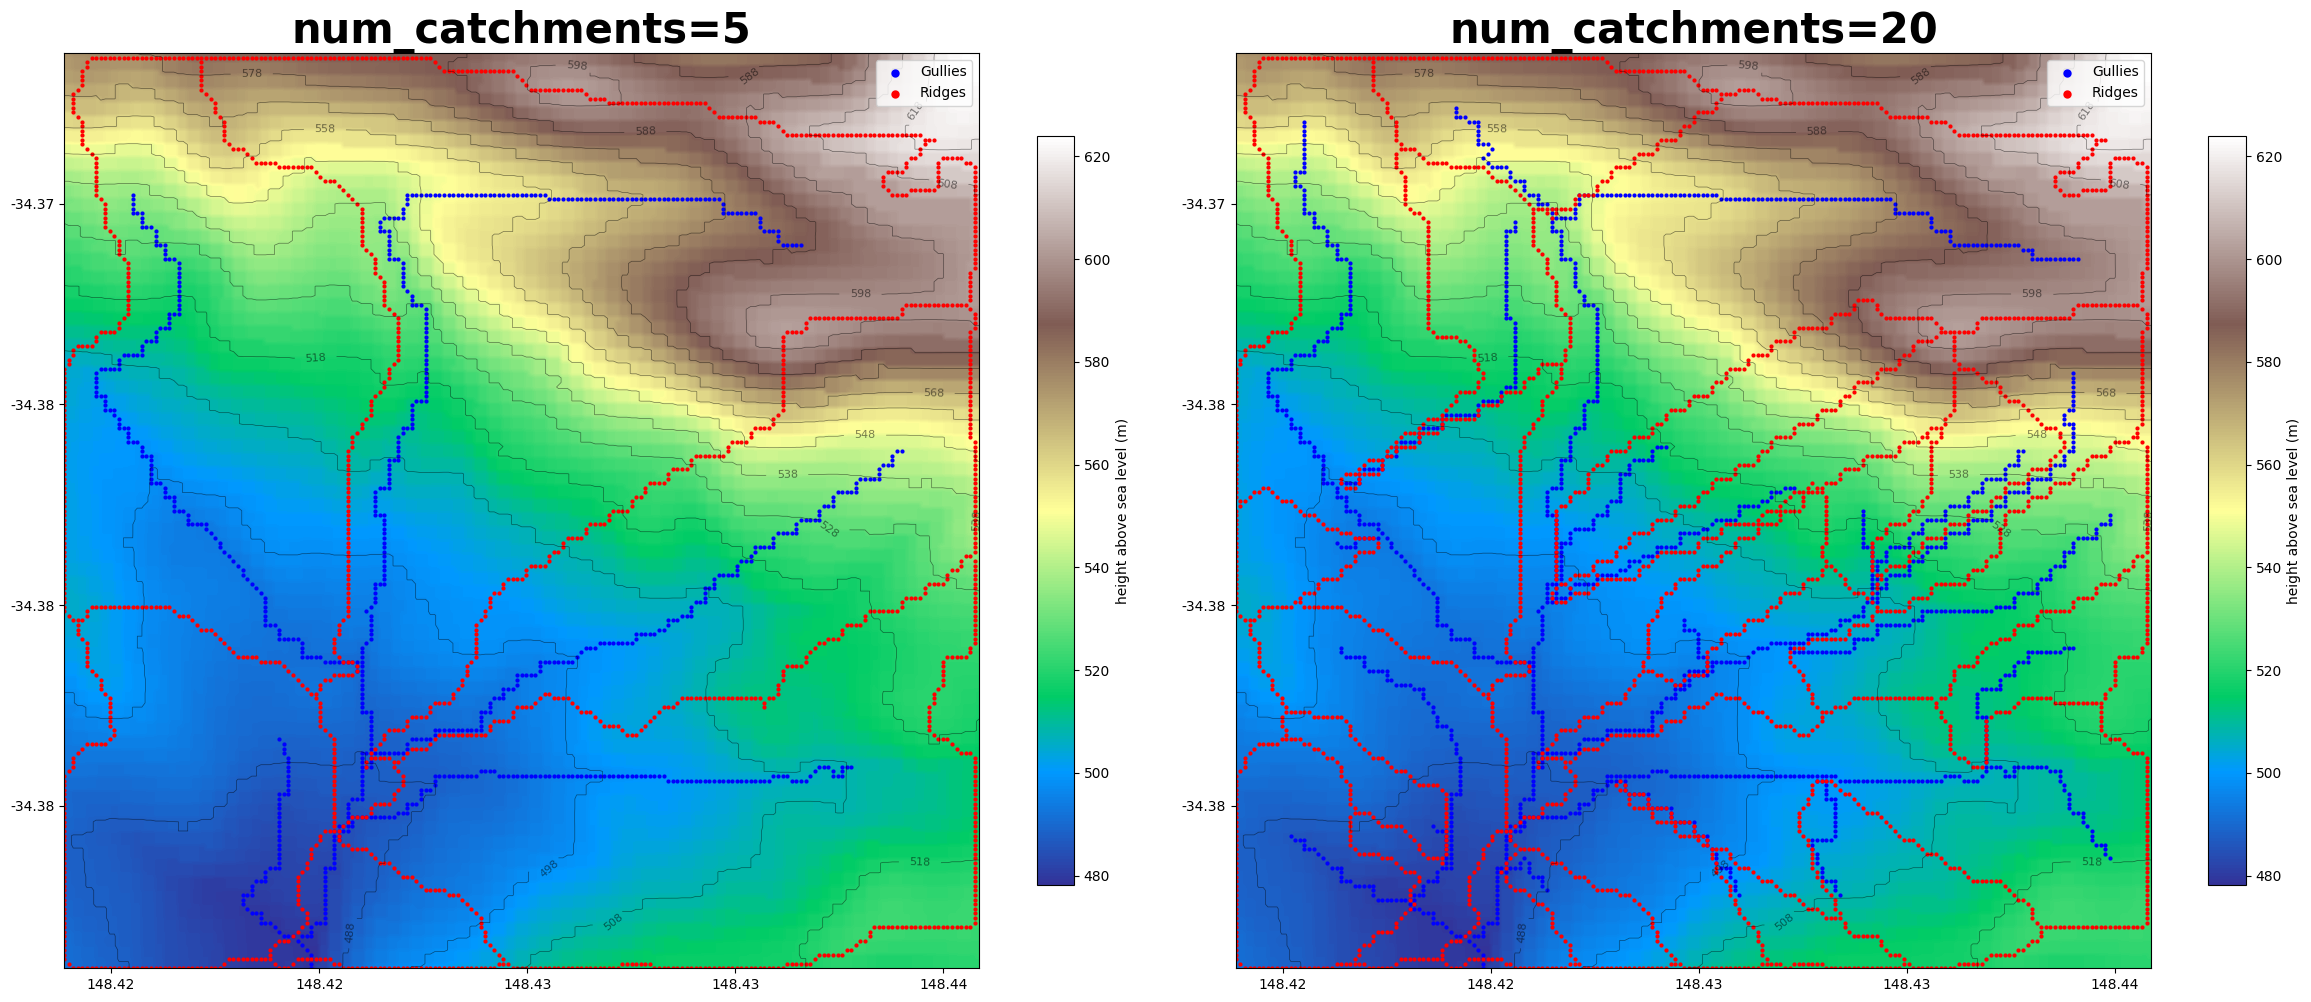

In [5]:
plot_catchments_sidebyside(ds5, ds20, title1='num_catchments=5', title2='num_catchments=20')

## Command Line Interface

In [6]:
!python -m shelterbelts.indices.catchments --help

usage: catchments.py [-h] [--outdir OUTDIR] [--stub STUB] [--tmpdir TMPDIR]
                     [--num_catchments NUM_CATCHMENTS] [--no-save-tif]
                     [--no-plot]
                     terrain_tif

positional arguments:
  terrain_tif           Path to the DEM (Digital Elevation Model) GeoTIFF file

options:
  -h, --help            show this help message and exit
  --outdir OUTDIR       Output directory for saving results (default: current
                        directory)
  --stub STUB           Prefix for output filenames (default: TEST)
  --tmpdir TMPDIR       Temporary folder to save terrain_tif as float64 for
                        pysheds (default: current directory)
  --num_catchments NUM_CATCHMENTS
                        The number of catchments to find (default: 10)
  --no-save-tif         Disable saving GeoTIFF output (default: enabled)
  --no-plot             Disable PNG visualisation (default: enabled)


In [7]:
!python -m shelterbelts.indices.catchments {dem_file} --num_catchments 7 --stub command_line

Saved: ./command_line_gullies.tif
Saved: ./command_line_ridges.tif
Saved: ./command_line_gullies_and_ridges.png


### Cleanup
Remove the output files created by this notebook

In [8]:
# !rm *.tif
# !rm *.png
# !rm *.xml